Loaded flight data from: flight_environment_dataset.csv
Loaded AQI data from: clean_aqi.csv
Flight dataset shape: (27626, 26)
AQI dataset shape: (35064, 16)

Merged dataset shape: (27626, 29)
Label counts:
able_to_land
Landed          27306
Did not land      320
Name: count, dtype: int64

Rows: 27626
Numeric features: 19
Categorical features: ['airline', 'origin_city', 'origin_iata']

Model training complete.

Evaluation:
Accuracy: 0.9215
Precision - landed class: 0.9933
Recall - landed class:    0.9268
F1 - landed class:        0.9589
Log loss:                 0.2489
ROC AUC - landed class:   0.7857
Average precision - unsafe class: 0.0741

Classification Report:
              precision    recall  f1-score   support

Did not land       0.07      0.47      0.12        64
      Landed       0.99      0.93      0.96      5462

    accuracy                           0.92      5526
   macro avg       0.53      0.70      0.54      5526
weighted avg       0.98      0.92      0.95      5526



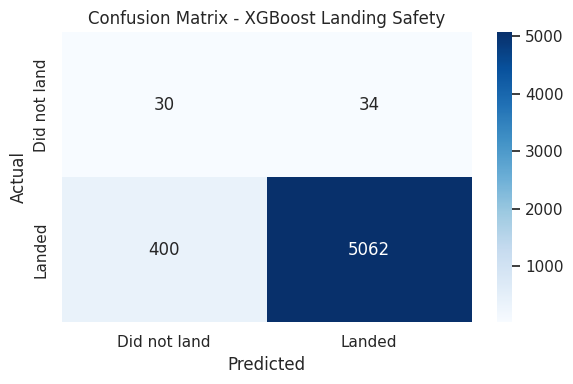


Top feature importances:


,feature,gain
0,cat__airline_Wizz Air,236.701202
1,num__is_winter_month,210.086197
2,cat__origin_iata_AYT,123.275970
3,cat__origin_city_Hurghada,106.832153
4,cat__airline_Lufthansa,103.644272
5,cat__airline_Croatia Airlines,103.262123
6,cat__airline_flydubai,98.298294
7,cat__origin_iata_BGY,91.790939
8,cat__airline_Eurowings,90.725647
9,cat__origin_iata_LTN,90.197289


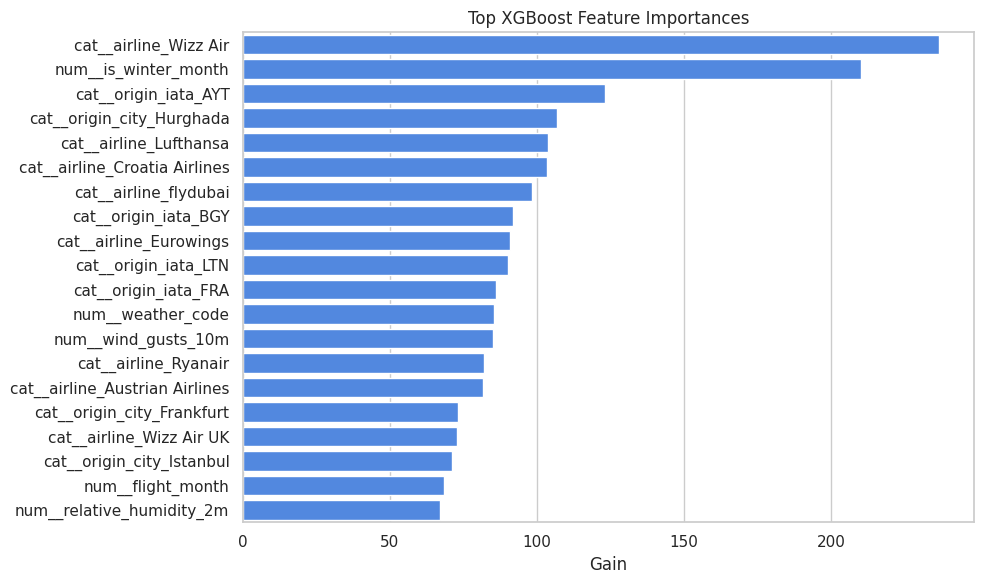


Example prediction:
Prediction: Landed
Predicted probability of landing: 0.952


,airline,origin_city,origin_iata,arrival_hour,flight_day_of_week,flight_month,is_winter_month,european_aqi,pm10,pm2_5,...,precipitation,snowfall,cloud_cover,wind_speed_10m,wind_gusts_10m,weather_code,aqi_hour,aqi_day_of_week,aqi_month,smog_risk
14478,Air Cairo,Hurghada,HRG,6,4,8,0,27,15.1,10.4,...,0.0,0.0,42,1.3,7.9,1,6,4,8,0


In [2]:
# XGBoost landing safety model

#if a package is missing, installs it automatically
import os
import sys
import subprocess

try:
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import xgboost as xgb
    from sklearn.compose import ColumnTransformer
    from sklearn.metrics import (
        accuracy_score,
        average_precision_score,
        classification_report,
        confusion_matrix,
        f1_score,
        log_loss,
        precision_score,
        recall_score,
        roc_auc_score,
    )
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.utils.class_weight import compute_sample_weight
except ModuleNotFoundError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "xgboost",
        "scikit-learn",
        "seaborn",
    ])
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import xgboost as xgb
    from sklearn.compose import ColumnTransformer
    from sklearn.metrics import (
        accuracy_score,
        average_precision_score,
        classification_report,
        confusion_matrix,
        f1_score,
        log_loss,
        precision_score,
        recall_score,
        roc_auc_score,
    )
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.utils.class_weight import compute_sample_weight

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


#load datasets. Put both CSV files beside this notebook, or in a data folder.
FLIGHT_CSV = "flight_environment_dataset.csv"
AQI_CSV = "clean_aqi.csv"

def get_csv_path(filename):
    possible_paths = [
        filename,
        os.path.join("data", filename),
        os.path.join("..", filename),
    ]
    for file_path in possible_paths:
        if os.path.exists(file_path):
            return file_path
    return None

flight_csv_path = get_csv_path(FLIGHT_CSV)
aqi_csv_path = get_csv_path(AQI_CSV)

if flight_csv_path is None or aqi_csv_path is None:
    try:
        from google.colab import files
        print("Upload flight_environment_dataset.csv and clean_aqi.csv")
        files.upload()
        flight_csv_path = get_csv_path(FLIGHT_CSV)
        aqi_csv_path = get_csv_path(AQI_CSV)
    except ModuleNotFoundError:
        pass

if flight_csv_path is None or aqi_csv_path is None:
    print("Current working directory:", os.getcwd())
    print("Files here:", os.listdir())
    raise FileNotFoundError("Could not find both CSV files. Put them beside the notebook or in a data folder.")

flight_df = pd.read_csv(flight_csv_path)
aqi_df = pd.read_csv(aqi_csv_path)

print("Loaded flight data from:", flight_csv_path)
print("Loaded AQI data from:", aqi_csv_path)
print("Flight dataset shape:", flight_df.shape)
print("AQI dataset shape:", aqi_df.shape)


#merging flights with hourly AQI data.
LABEL_COLUMN = "able_to_land"
FLIGHT_TIME_COLUMN = "scheduled_hour"
AQI_TIME_COLUMN = "datetime"

flight_df[FLIGHT_TIME_COLUMN] = pd.to_datetime(flight_df[FLIGHT_TIME_COLUMN])
flight_df["scheduled_arrival_datetime"] = pd.to_datetime(flight_df["scheduled_arrival_datetime"])
aqi_df[AQI_TIME_COLUMN] = pd.to_datetime(aqi_df[AQI_TIME_COLUMN])

environment_columns_already_in_flight = [
    "aqi_datetime",
    "european_aqi",
    "pm10",
    "pm2_5",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "snowfall",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "weather_code",
    "smog_risk",
]

flight_base = flight_df.drop(
    columns=[c for c in environment_columns_already_in_flight if c in flight_df.columns],
    errors="ignore",
)

combined_df = flight_base.merge(
    aqi_df,
    left_on=FLIGHT_TIME_COLUMN,
    right_on=AQI_TIME_COLUMN,
    how="inner",
    validate="many_to_one",
)

combined_df = combined_df.rename(
    columns={
        "day_of_week_x": "flight_day_of_week",
        "month_x": "flight_month",
        "day_of_week_y": "aqi_day_of_week",
        "month_y": "aqi_month",
        "hour": "aqi_hour",
    }
)

print("\nMerged dataset shape:", combined_df.shape)
print("Label counts:")
print(combined_df[LABEL_COLUMN].value_counts().rename(index={0: "Did not land", 1: "Landed"}))


#build features and labels. Status excluded because it leaks the final outcome
leakage_or_identifier_columns = [
    LABEL_COLUMN,
    "status",
    "flight_number",
    "callsign",
    "scheduled_arrival_datetime",
    FLIGHT_TIME_COLUMN,
    AQI_TIME_COLUMN,
]

X = combined_df.drop(columns=leakage_or_identifier_columns, errors="ignore")
y = combined_df[LABEL_COLUMN].astype(int)

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("\nRows:", len(X))
print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)


#training XGBoost classifier
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", one_hot_encoder, categorical_features),
    ],
    remainder="drop",
)

model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", model),
    ]
)

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)
print("\nModel training complete.")


#evaluating model
y_pred = pipeline.predict(X_test)
y_proba_landed = pipeline.predict_proba(X_test)[:, 1]
y_unsafe = (y_test == 0).astype(int)
unsafe_scores = 1 - y_proba_landed

print("\nEvaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision - landed class: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall - landed class:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1 - landed class:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Log loss:                 {log_loss(y_test, y_proba_landed):.4f}")
print(f"ROC AUC - landed class:   {roc_auc_score(y_test, y_proba_landed):.4f}")
print(f"Average precision - unsafe class: {average_precision_score(y_unsafe, unsafe_scores):.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Did not land", "Landed"],
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did not land", "Landed"],
    yticklabels=["Did not land", "Landed"],
)
plt.title("Confusion Matrix - XGBoost Landing Safety")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


#feature importance
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
booster = pipeline.named_steps["model"].get_booster()
gain_scores = booster.get_score(importance_type="gain")

importance_rows = []
for encoded_name, gain in gain_scores.items():
    feature_index = int(encoded_name[1:])
    importance_rows.append(
        {
            "feature": feature_names[feature_index],
            "gain": gain,
        }
    )

importance_df = (
    pd.DataFrame(importance_rows)
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

print("\nTop feature importances:")
display(importance_df.head(20))

top_n = min(20, len(importance_df))
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(top_n),
    y="feature",
    x="gain",
    color="#3b82f6",
)
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Gain")
plt.ylabel("")
plt.tight_layout()
plt.show()


#example prediction
example_row = X_test.iloc[[0]]
predicted_label = int(pipeline.predict(example_row)[0])
predicted_probability_landed = float(pipeline.predict_proba(example_row)[0, 1])

print("\nExample prediction:")
print("Prediction:", "Landed" if predicted_label == 1 else "Did not land")
print(f"Predicted probability of landing: {predicted_probability_landed:.3f}")
display(example_row)